# Movie Recommendation System with Collaborative Filtering

**Machine Learning Final Exam Project**

In this project I build a simple movie recommendation system. The main idea is to use ratings from other users and try to recommend movies that a selected user has not watched yet.

I chose this topic because recommendation systems are used in real apps like Netflix, YouTube and Spotify, so it is an interesting example of machine learning in everyday life.


## 1. Problem formulation

The problem is: **how can we recommend movies to a user based on previous ratings?**

The input data is a list of users, movies and ratings. The output should be a list of movies that the user may like.

This is a collaborative filtering problem. Instead of looking at the movie description, we look at rating patterns. For example, if two users liked many of the same movies, they may also like similar new movies.

### Objectives

1. Load and inspect the MovieLens dataset.
2. Do basic exploratory data analysis.
3. Create a user-movie ratings matrix.
4. Build a user-based recommender.
5. Build an item-based recommender.
6. Compare the results using RMSE and MAE.
7. Explain the advantages and limitations.


## 2. Mathematical background

The ratings can be written as a matrix. Rows are users and columns are movies.

If user `u` gives movie `i` a rating, then this value is stored in the matrix. Many values are empty because every user rates only a small part of all movies.

### Cosine similarity

Cosine similarity compares two vectors by their direction. In this project the vectors are user rating rows or movie rating columns.

\[
similarity(A,B)=rac{A \cdot B}{||A|| \cdot ||B||}
\]

A higher value means the two users or movies are more similar.

### Prediction idea

For user-based collaborative filtering, the predicted rating is based on ratings from similar users. A simple version is:

\[
\hat r_{u,i}=rac{\sum_v sim(u,v)r_{v,i}}{\sum_v |sim(u,v)|}
\]

This means that users with higher similarity have more influence on the prediction.


In [1]:
# I import the libraries that are needed for data analysis, plots and ML calculations.
from pathlib import Path
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

pd.set_option("display.max_columns", 50)

## 3. Dataset loading

I use the MovieLens 100K dataset. It contains 100,000 ratings from 943 users and 1,682 movies.

The code below downloads the dataset automatically if it is not already in the `data` folder.


In [2]:
# Create a local data folder and download the dataset only once.
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
zip_path = DATA_DIR / "ml-100k.zip"
extract_path = DATA_DIR / "ml-100k"

if not extract_path.exists():
    print("Downloading MovieLens 100K dataset...")
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(DATA_DIR)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset already available.")

Dataset already available.


In [3]:
ratings = pd.read_csv(
    extract_path / "u.data",
    sep="\t",
    names=["user_id", "movie_id", "rating", "timestamp"],
    encoding="latin-1"
)

movies = pd.read_csv(
    extract_path / "u.item",
    sep="|",
    names=["movie_id", "title", "release_date", "video_release_date", "IMDb_URL",
           "unknown", "Action", "Adventure", "Animation", "Children", "Comedy", "Crime",
           "Documentary", "Drama", "Fantasy", "Film-Noir", "Horror", "Musical", "Mystery",
           "Romance", "Sci-Fi", "Thriller", "War", "Western"],
    encoding="latin-1"
)

ratings.head(), movies[["movie_id", "title"]].head()

(   user_id  movie_id  rating  timestamp
 0      196       242       3  881250949
 1      186       302       3  891717742
 2       22       377       1  878887116
 3      244        51       2  880606923
 4      166       346       1  886397596,
    movie_id              title
 0         1   Toy Story (1995)
 1         2   GoldenEye (1995)
 2         3  Four Rooms (1995)
 3         4  Get Shorty (1995)
 4         5     Copycat (1995))

## 4. Data overview and quality checks

Before building the model, I check the size of the data, the rating values, missing values and duplicated rows. This helps me make sure the dataset is loaded correctly.


In [4]:
# Basic checks to understand if the data looks correct.
print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)
print("Number of users:", ratings["user_id"].nunique())
print("Number of movies rated:", ratings["movie_id"].nunique())
print("Rating values:", sorted(ratings["rating"].unique()))
print("Missing values in ratings:")
print(ratings.isna().sum())
print("Duplicate rows:", ratings.duplicated().sum())

Ratings shape: (100000, 4)
Movies shape: (1682, 24)
Number of users: 943
Number of movies rated: 1682
Rating values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Missing values in ratings:
user_id      0
movie_id     0
rating       0
timestamp    0
dtype: int64
Duplicate rows: 0


## 5. Exploratory data analysis

In this section I look at the rating distribution and which movies have the most ratings. This gives a better understanding of the data before modeling.


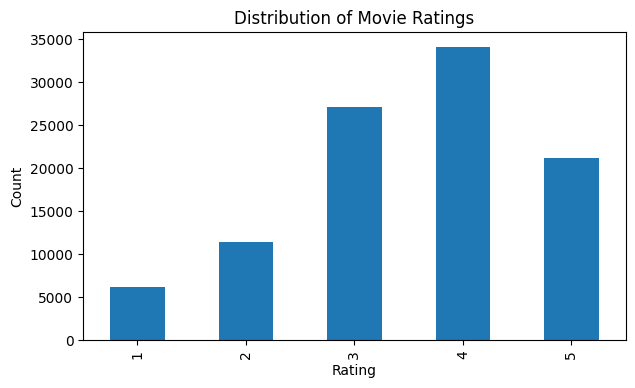

In [5]:
plt.figure(figsize=(7, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [6]:
ratings_per_movie = ratings.groupby("movie_id").size().sort_values(ascending=False)
top_movies = ratings_per_movie.head(20).reset_index(name="num_ratings").merge(
    movies[["movie_id", "title"]], on="movie_id", how="left"
)
top_movies[["title", "num_ratings"]]

,title,num_ratings
0,Star Wars (1977),583
1,Contact (1997),509
2,Fargo (1996),508
3,Return of the Jedi (1983),507
4,Liar Liar (1997),485
5,"English Patient, The (1996)",481
6,Scream (1996),478
7,Toy Story (1995),452
8,Air Force One (1997),431
9,Independence Day (ID4) (1996),429


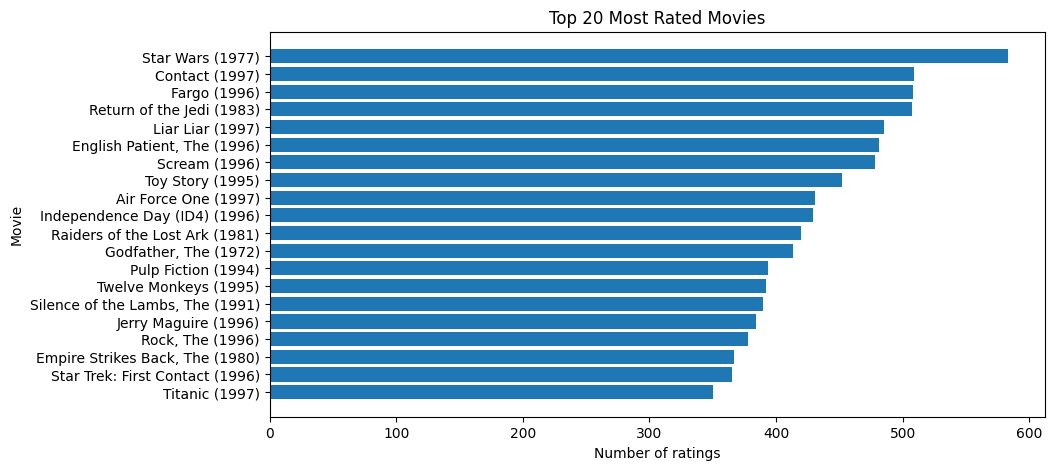

In [7]:
plt.figure(figsize=(10, 5))
plt.barh(top_movies["title"][::-1], top_movies["num_ratings"][::-1])
plt.title("Top 20 Most Rated Movies")
plt.xlabel("Number of ratings")
plt.ylabel("Movie")
plt.show()

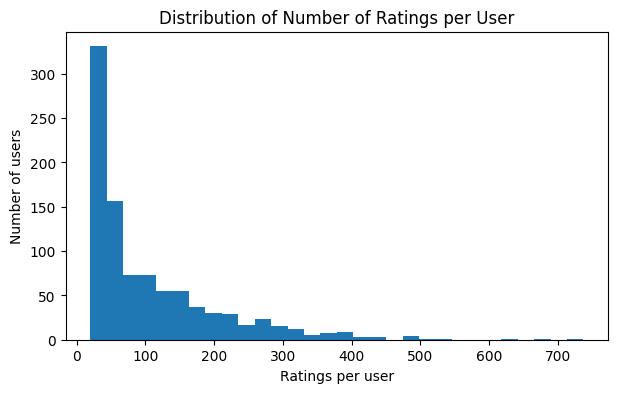

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
dtype: float64

In [8]:
ratings_per_user = ratings.groupby("user_id").size()
plt.figure(figsize=(7, 4))
plt.hist(ratings_per_user, bins=30)
plt.title("Distribution of Number of Ratings per User")
plt.xlabel("Ratings per user")
plt.ylabel("Number of users")
plt.show()
ratings_per_user.describe()

## 6. Building the user-movie matrix

The recommender needs the data in matrix form. Each row is a user and each column is a movie.

Missing values mean that the user did not rate the movie. For similarity calculations I fill them with 0, but I still keep the original matrix with missing values for checking which movies are unrated.


In [9]:
user_movie_matrix = ratings.pivot_table(index="user_id", columns="movie_id", values="rating")
user_movie_filled = user_movie_matrix.fillna(0)
print("User-movie matrix shape:", user_movie_matrix.shape)
user_movie_matrix.head()

User-movie matrix shape: (943, 1682)


movie_id,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,...,1658,1659,1660,1661,1662,1663,1664,1665,1666,1667,1668,1669,1670,1671,1672,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,2.0,5.0,5.0,5.0,5.0,5.0,3.0,4.0,5.0,4.0,1.0,4.0,4.0,3.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,4.0,4.0,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,NaN,NaN,NaN,3.0,NaN,NaN,4.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 7. User-based collaborative filtering

User-based collaborative filtering recommends movies by finding users with similar taste.

Example: if User 50 and User 100 rated many movies similarly, then movies liked by User 100 can be recommended to User 50.


In [10]:
user_similarity = cosine_similarity(user_movie_filled)
user_similarity_df = pd.DataFrame(user_similarity, index=user_movie_filled.index, columns=user_movie_filled.index)
user_similarity_df.iloc[:5, :5]

user_id,1,2,3,4,5
user_id,,,,,
1,1.000000,0.166931,0.047460,0.064358,0.378475
2,0.166931,1.000000,0.110591,0.178121,0.072979
3,0.047460,0.110591,1.000000,0.344151,0.021245
4,0.064358,0.178121,0.344151,1.000000,0.031804
5,0.378475,0.072979,0.021245,0.031804,1.000000


In [11]:
# This function gives recommendations using similar users.
def recommend_user_based(user_id, user_movie_matrix, user_similarity_df, movies, n_recommendations=10):
    "Recommend movies using weighted ratings from similar users."
    if user_id not in user_movie_matrix.index:
        raise ValueError(f"User {user_id} not found.")
    user_ratings = user_movie_matrix.loc[user_id]
    unrated_movies = user_ratings[user_ratings.isna()].index
    similarities = user_similarity_df.loc[user_id].drop(user_id)
    weighted_scores = {}
    for movie_id in unrated_movies:
        movie_ratings = user_movie_matrix[movie_id].dropna()
        common_users = similarities.index.intersection(movie_ratings.index)
        if len(common_users) == 0:
            continue
        sim_scores = similarities.loc[common_users]
        rating_values = movie_ratings.loc[common_users]
        denominator = np.abs(sim_scores).sum()
        if denominator != 0:
            weighted_scores[movie_id] = np.dot(sim_scores, rating_values) / denominator
    return (pd.DataFrame.from_dict(weighted_scores, orient="index", columns=["predicted_rating"])
            .sort_values("predicted_rating", ascending=False)
            .head(n_recommendations)
            .reset_index()
            .rename(columns={"index": "movie_id"})
            .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
            [["movie_id", "title", "predicted_rating"]])

recommend_user_based(50, user_movie_matrix, user_similarity_df, movies, 10)

,movie_id,title,predicted_rating
0,1467,"Saint of Fort Washington, The (1993)",5.0
1,1599,Someone Else's America (1995),5.0
2,1500,Santa with Muscles (1996),5.0
3,1536,Aiqing wansui (1994),5.0
4,1189,Prefontaine (1997),5.0
5,1653,Entertaining Angels: The Dorothy Day Story (1996),5.0
6,1122,They Made Me a Criminal (1939),5.0
7,814,"Great Day in Harlem, A (1994)",5.0
8,1293,Star Kid (1997),5.0
9,1201,Marlene Dietrich: Shadow and Light (1996),5.0


## 8. Item-based collaborative filtering

Item-based collaborative filtering looks for similar movies instead of similar users.

Example: if a user liked one movie, we can recommend other movies that were rated similarly by many users.


In [12]:
item_similarity = cosine_similarity(user_movie_filled.T)
item_similarity_df = pd.DataFrame(item_similarity, index=user_movie_filled.columns, columns=user_movie_filled.columns)
item_similarity_df.iloc[:5, :5]

movie_id,1,2,3,4,5
movie_id,,,,,
1,1.000000,0.402382,0.330245,0.454938,0.286714
2,0.402382,1.000000,0.273069,0.502571,0.318836
3,0.330245,0.273069,1.000000,0.324866,0.212957
4,0.454938,0.502571,0.324866,1.000000,0.334239
5,0.286714,0.318836,0.212957,0.334239,1.000000


In [13]:
# This function gives recommendations using similar movies.
def recommend_item_based(user_id, user_movie_matrix, item_similarity_df, movies, n_recommendations=10):
    "Recommend movies using similarities between movies."
    if user_id not in user_movie_matrix.index:
        raise ValueError(f"User {user_id} not found.")
    user_ratings = user_movie_matrix.loc[user_id].dropna()
    candidate_movies = user_movie_matrix.columns.difference(user_ratings.index)
    scores = {}
    for movie_id in candidate_movies:
        similarities = item_similarity_df.loc[movie_id, user_ratings.index]
        denominator = np.abs(similarities).sum()
        if denominator != 0:
            scores[movie_id] = np.dot(similarities, user_ratings.values) / denominator
    return (pd.DataFrame.from_dict(scores, orient="index", columns=["predicted_rating"])
            .sort_values("predicted_rating", ascending=False)
            .head(n_recommendations)
            .reset_index()
            .rename(columns={"index": "movie_id"})
            .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
            [["movie_id", "title", "predicted_rating"]])

recommend_item_based(50, user_movie_matrix, item_similarity_df, movies, 10)

,movie_id,title,predicted_rating
0,1556,Condition Red (1995),4.722759
1,1472,"Visitors, The (Visiteurs, Les) (1993)",4.340693
2,1619,All Things Fair (1996),4.245522
3,1671,"Further Gesture, A (1996)",4.208901
4,1433,Men of Means (1998),4.191468
5,1604,He Walked by Night (1948),4.088035
6,1551,"Glass Shield, The (1994)",4.086577
7,1547,"Show, The (1995)",4.085866
8,361,Incognito (1997),4.074564
9,1191,"Letter From Death Row, A (1998)",4.066681


## 9. Train-test evaluation

To check the recommender, I split the ratings into training and testing data.

I compare three approaches:

1. A baseline model that always predicts the average rating.
2. User-based collaborative filtering.
3. Item-based collaborative filtering.

The metrics are:

- **RMSE**: gives larger penalty to bigger mistakes.
- **MAE**: average absolute prediction error.


In [14]:
train_data, test_data = train_test_split(ratings[["user_id", "movie_id", "rating"]], test_size=0.2, random_state=42)
train_matrix = train_data.pivot_table(index="user_id", columns="movie_id", values="rating")
train_filled = train_matrix.fillna(0)
train_user_similarity = pd.DataFrame(cosine_similarity(train_filled), index=train_filled.index, columns=train_filled.index)
train_item_similarity = pd.DataFrame(cosine_similarity(train_filled.T), index=train_filled.columns, columns=train_filled.columns)
global_mean = train_data["rating"].mean()
print("Training ratings:", len(train_data))
print("Testing ratings:", len(test_data))
print("Global mean rating:", round(global_mean, 3))

Training ratings: 80000
Testing ratings: 20000
Global mean rating: 3.531


In [15]:
# Prediction helper functions used for evaluation.
def predict_user_based(user_id, movie_id, train_matrix, similarity_df, fallback):
    if user_id not in train_matrix.index or movie_id not in train_matrix.columns:
        return fallback
    movie_ratings = train_matrix[movie_id].dropna()
    if movie_ratings.empty:
        return fallback
    similarities = similarity_df.loc[user_id, movie_ratings.index].drop(labels=[user_id], errors="ignore")
    movie_ratings = movie_ratings.loc[similarities.index]
    denominator = np.abs(similarities).sum()
    if denominator == 0:
        return fallback
    return float(np.clip(np.dot(similarities, movie_ratings) / denominator, 1, 5))

def predict_item_based(user_id, movie_id, train_matrix, item_similarity_df, fallback):
    if user_id not in train_matrix.index or movie_id not in train_matrix.columns:
        return fallback
    user_ratings = train_matrix.loc[user_id].dropna()
    if user_ratings.empty:
        return fallback
    common_movies = item_similarity_df.columns.intersection(user_ratings.index)
    similarities = item_similarity_df.loc[movie_id, common_movies]
    ratings_values = user_ratings.loc[common_movies]
    denominator = np.abs(similarities).sum()
    if denominator == 0:
        return fallback
    return float(np.clip(np.dot(similarities, ratings_values) / denominator, 1, 5))

In [16]:
eval_sample = test_data.sample(n=min(5000, len(test_data)), random_state=42).copy()
eval_sample["baseline_pred"] = global_mean
eval_sample["user_based_pred"] = [predict_user_based(r.user_id, r.movie_id, train_matrix, train_user_similarity, global_mean) for r in eval_sample.itertuples(index=False)]
eval_sample["item_based_pred"] = [predict_item_based(r.user_id, r.movie_id, train_matrix, train_item_similarity, global_mean) for r in eval_sample.itertuples(index=False)]

def regression_metrics(y_true, y_pred):
    return {"RMSE": np.sqrt(mean_squared_error(y_true, y_pred)), "MAE": mean_absolute_error(y_true, y_pred)}

results = pd.DataFrame({
    "Baseline global mean": regression_metrics(eval_sample["rating"], eval_sample["baseline_pred"]),
    "User-based CF": regression_metrics(eval_sample["rating"], eval_sample["user_based_pred"]),
    "Item-based CF": regression_metrics(eval_sample["rating"], eval_sample["item_based_pred"]),
}).T
results

,RMSE,MAE
Baseline global mean,1.108947,0.929499
User-based CF,1.001616,0.795338
Item-based CF,1.005820,0.798649


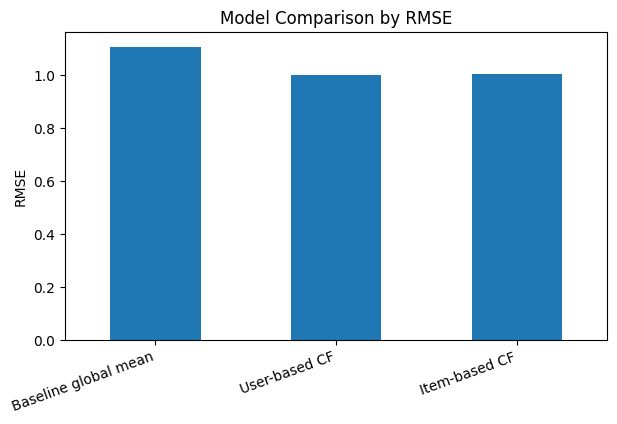

In [17]:
plt.figure(figsize=(7, 4))
results["RMSE"].plot(kind="bar")
plt.title("Model Comparison by RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=20, ha="right")
plt.show()

## 10. Recommendation examples

Here I test the recommender for one sample user. First I show some movies the user already rated highly, then I generate recommendations.


In [18]:
sample_user = 50
already_rated = (ratings[ratings["user_id"] == sample_user]
                 .merge(movies[["movie_id", "title"]], on="movie_id", how="left")
                 .sort_values("rating", ascending=False)
                 [["title", "rating"]]
                 .head(10))
already_rated

,title,rating
3,Trainspotting (1996),5
2,"Pillow Book, The (1995)",5
4,Anne Frank Remembered (1995),5
16,Basquiat (1996),5
12,Everyone Says I Love You (1996),5
13,Lost Highway (1997),5
15,I Shot Andy Warhol (1996),5
10,"People vs. Larry Flynt, The (1996)",5
18,Things to Do in Denver when You're Dead (1995),4
22,"Young Poisoner's Handbook, The (1995)",4


In [19]:
recommend_user_based(sample_user, user_movie_matrix, user_similarity_df, movies, 10)

,movie_id,title,predicted_rating
0,1467,"Saint of Fort Washington, The (1993)",5.0
1,1599,Someone Else's America (1995),5.0
2,1500,Santa with Muscles (1996),5.0
3,1536,Aiqing wansui (1994),5.0
4,1189,Prefontaine (1997),5.0
5,1653,Entertaining Angels: The Dorothy Day Story (1996),5.0
6,1122,They Made Me a Criminal (1939),5.0
7,814,"Great Day in Harlem, A (1994)",5.0
8,1293,Star Kid (1997),5.0
9,1201,Marlene Dietrich: Shadow and Light (1996),5.0


In [20]:
recommend_item_based(sample_user, user_movie_matrix, item_similarity_df, movies, 10)

,movie_id,title,predicted_rating
0,1556,Condition Red (1995),4.722759
1,1472,"Visitors, The (Visiteurs, Les) (1993)",4.340693
2,1619,All Things Fair (1996),4.245522
3,1671,"Further Gesture, A (1996)",4.208901
4,1433,Men of Means (1998),4.191468
5,1604,He Walked by Night (1948),4.088035
6,1551,"Glass Shield, The (1994)",4.086577
7,1547,"Show, The (1995)",4.085866
8,361,Incognito (1997),4.074564
9,1191,"Letter From Death Row, A (1998)",4.066681


## 11. Discussion

### Strengths

- The method is easy to understand.
- It only needs user ratings.
- Cosine similarity gives a clear mathematical way to compare users or movies.

### Limitations

- New users and new movies are hard to recommend because there are no ratings yet. This is called the cold-start problem.
- Missing ratings do not mean the user disliked the movie. They only mean the user did not rate it.
- The model does not understand genres, actors, plot or language.

### Future improvements

If I continued the project, I would try matrix factorization or combine ratings with movie genres. I would also test more users and compare more evaluation methods.


## 12. Conclusion

In this project I created a simple movie recommendation system using collaborative filtering.

The project showed the full machine learning workflow: loading data, checking data quality, exploring the data, explaining the math, building models and evaluating them.

The main result is that collaborative filtering can create useful movie recommendations, but it also has important limitations such as sparse data and cold-start problems.


## 13. References

- GroupLens Research, MovieLens 100K Dataset.
- Scikit-learn documentation for cosine similarity and evaluation metrics.
- Pandas documentation for data manipulation and pivot tables.
- Ricci, F., Rokach, L., & Shapira, B., *Recommender Systems Handbook*.
